In [199]:
import pandas
import matplotlib.pyplot as plt
import numpy
import seaborn as sns


## Import and Check the data

In [200]:
# Load the dataset
df = pandas.read_csv('car_price_prediction.csv')

In [201]:
# Check the first few rows of the dataset
df.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [202]:
# Check the column names and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  str    
 3   Manufacturer      19237 non-null  str    
 4   Model             19237 non-null  str    
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  str    
 7   Leather interior  19237 non-null  str    
 8   Fuel type         19237 non-null  str    
 9   Engine volume     19237 non-null  str    
 10  Mileage           19237 non-null  str    
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  str    
 13  Drive wheels      19237 non-null  str    
 14  Doors             19237 non-null  str    
 15  Wheel             19237 non-null  str    
 16  Color             19237 non-null  str    
 17  Airb

In [203]:
# Simplify column names for easier access
df = df.rename(columns={
    'ID': 'id',
    'Price': 'price',
    'Levy': 'levy',
    'Manufacturer': 'manufacturer',
    'Model': 'model',
    'Prod. year': 'year',
    'Category': 'category',
    'Leather interior': 'leather_interior',
    'Fuel type': 'fuel',
    'Engine volume': 'engine_volume',
    'Mileage': 'mileage',
    'Cylinders': 'cylinders',
    'Gear box type': 'gear_type',
    'Drive wheels': 'drive_wheels',
    'Doors': 'doors',
    'Wheel': 'wheel',
    'Color': 'color',
    'Airbags': 'airbags'
})

# Quick check
df.columns

Index(['id', 'price', 'levy', 'manufacturer', 'model', 'year', 'category',
       'leather_interior', 'fuel', 'engine_volume', 'mileage', 'cylinders',
       'gear_type', 'drive_wheels', 'doors', 'wheel', 'color', 'airbags'],
      dtype='str')

# Clean the data
To make the data usable for training. We begin by removing faulty prices.

1. levy - clear character symbols from dataset. change to numeric.
2. mileage - clear 'km' unit and change to numeric.
3. manufacturer - map the text values to numeric replacements.
4. fuel - map the text values to numeric replacements
5. category - map the text values to numeric replacements
6. gear_type - map the text values to numeric replacements
7. engine_volume - clear character data.

In [240]:
df = df[(df['price'] > 100) & (df['price'] < 600000) & (df['levy'] > 0)]

In [205]:
# 1) levy: remove '-' and convert to numeric
df['levy'] = df['levy'].replace('-', 0)
df['levy'] = pandas.to_numeric(df['levy'], errors='coerce')

In [206]:
# 2) mileage: remove 'km' and separators, then convert to numeric
df['mileage'] = (
    df['mileage']
    .astype(str)
    .str.replace('km', '', regex=False)
    .str.strip()
)
df['mileage'] = pandas.to_numeric(df['mileage'], errors='coerce')

In [207]:

# 3) manufacturer: map text values to numeric codes
# Sort manufacturers by median price.
manufacturer_sorted = (
    df.groupby('manufacturer')['price']
    .median()
    .sort_values()
    .index
 )

# 1. `enumerate(...)`: Assigns an integer index to each unique manufacturer, starting from 1.
# 2. `{name: code for code, name in ...}`: Create a mapping where each unique manufacturer (name) is mapped to its corresponding index (code).
manufacturer_map = {name: code for code, name in enumerate(manufacturer_sorted, start=1)}
df['manufacturer'] = df['manufacturer'].map(manufacturer_map)

print("Manufacturers ordered by median price (lowest to highest):")
print(manufacturer_map)

Manufacturers ordered by median price (lowest to highest):
{'ROLLS-ROYCE': 1, 'MOSKVICH': 2, 'ROVER': 3, 'GMC': 4, 'VAZ': 5, 'ACURA': 6, 'ZAZ': 7, 'SEAT': 8, 'UAZ': 9, 'CADILLAC': 10, 'DAIHATSU': 11, 'CHRYSLER': 12, 'MAZDA': 13, 'OPEL': 14, 'GAZ': 15, 'PONTIAC': 16, 'BUICK': 17, 'DAEWOO': 18, 'SAAB': 19, 'PEUGEOT': 20, 'CITROEN': 21, 'DODGE': 22, 'LEXUS': 23, 'NISSAN': 24, 'SUBARU': 25, 'AUDI': 26, 'ALFA ROMEO': 27, 'ISUZU': 28, 'VOLVO': 29, 'SUZUKI': 30, 'MITSUBISHI': 31, 'GREATWALL': 32, 'RENAULT': 33, 'HONDA': 34, 'MERCEDES-BENZ': 35, 'VOLKSWAGEN': 36, 'SKODA': 37, 'FIAT': 38, 'LANCIA': 39, 'TOYOTA': 40, 'FORD': 41, 'CHEVROLET': 42, 'SATURN': 43, 'BMW': 44, 'SCION': 45, 'LINCOLN': 46, 'MERCURY': 47, 'HAVAL': 48, 'KIA': 49, 'სხვა': 50, 'INFINITI': 51, 'HYUNDAI': 52, 'MINI': 53, 'JAGUAR': 54, 'JEEP': 55, 'MASERATI': 56, 'PORSCHE': 57, 'SSANGYONG': 58, 'HUMMER': 59, 'LAND ROVER': 60, 'TESLA': 61, 'ASTON MARTIN': 62, 'FERRARI': 63, 'BENTLEY': 64, 'LAMBORGHINI': 65}


In [208]:
# 4) fuel: map text values to numeric codes
fuel_type_sorted = (
    df.groupby('fuel')['price']
    .median()
    .sort_values()
    .index
)
fuel_map = {name: code for code, name in enumerate(fuel_type_sorted, start=1)}
df['fuel'] = df['fuel'].map(fuel_map)

print("Unique fuel types and their codes:")
print(fuel_map)


Unique fuel types and their codes:
{'CNG': 1, 'Hybrid': 2, 'LPG': 3, 'Petrol': 4, 'Hydrogen': 5, 'Diesel': 6, 'Plug-in Hybrid': 7}


In [209]:
# 5) category: map text values to numeric codes
# Similar to manufacturer mapping, we create a mapping for the 'category' column.
category_sorted = (
    df.groupby('category')['price']
    .median()
    .sort_values()
    .index
)

category_map = {name: code for code, name in enumerate(category_sorted, start=1)}
df['category'] = df['category'].map(category_map)

print("Unique categories and their codes:")
print(category_map)

Unique categories and their codes:
{'Goods wagon': 1, 'Limousine': 2, 'Hatchback': 3, 'Sedan': 4, 'Coupe': 5, 'Microbus': 6, 'Universal': 7, 'Minivan': 8, 'Cabriolet': 9, 'Jeep': 10, 'Pickup': 11}


In [210]:
# 6) gear_type: map text values to numeric codes
gear_type_map = {v: i for i, v in enumerate(sorted(df['gear_type'].dropna().unique()))}
df['gear_type'] = df['gear_type'].map(gear_type_map)

print("Unique gear types and their codes:")
print(gear_type_map)

Unique gear types and their codes:
{'Automatic': 0, 'Manual': 1, 'Tiptronic': 2, 'Variator': 3}


In [211]:
# 7) engine_volume: remove str and convert to numeric
df['engine_volume'] = (
    df['engine_volume']
    .astype(str)
    .str.replace('Turbo', '', regex=False)
    .str.strip()
)
df['engine_volume'] = pandas.to_numeric(df['engine_volume'], errors='coerce')

In [212]:
# Validate cleaned columns
df[['levy', 'mileage', 'manufacturer', 'fuel', 'category', 'gear_type', 'engine_volume']].info()

<class 'pandas.DataFrame'>
Index: 18856 entries, 0 to 19236
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   levy           18856 non-null  int64  
 1   mileage        18856 non-null  int64  
 2   manufacturer   18856 non-null  int64  
 3   fuel           18856 non-null  int64  
 4   category       18856 non-null  int64  
 5   gear_type      18856 non-null  int64  
 6   engine_volume  18856 non-null  float64
dtypes: float64(1), int64(6)
memory usage: 1.2 MB


## Visualise the data
To understand which features are likely to influence our target variable (price)

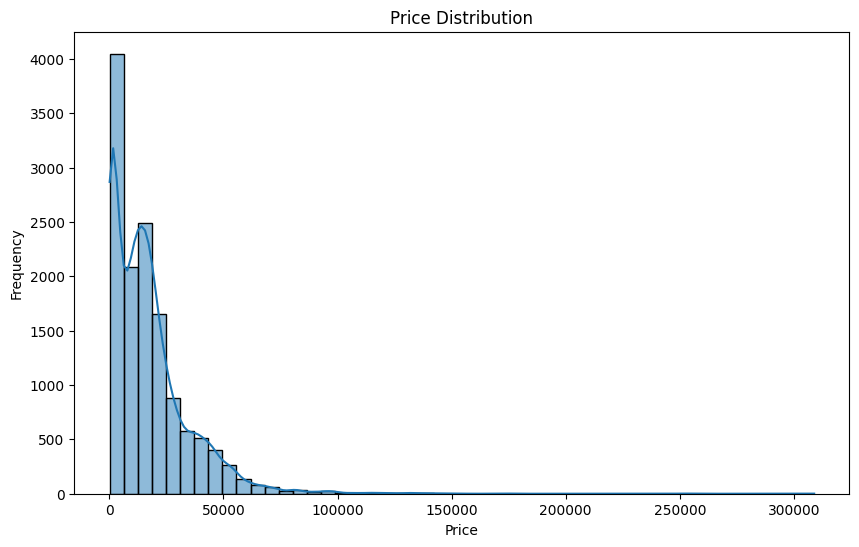

In [241]:
# Plot price on a heatmap to see the distribution and identify outliers
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

In [242]:
df[['price', 'year','levy','manufacturer', 'fuel','engine_volume', 'mileage', 'cylinders']].corr()['price'].sort_values(ascending=False)

price            1.000000
year             0.309295
fuel             0.286190
manufacturer     0.218437
levy             0.059742
engine_volume    0.029134
cylinders        0.007593
mileage         -0.003624
Name: price, dtype: float64

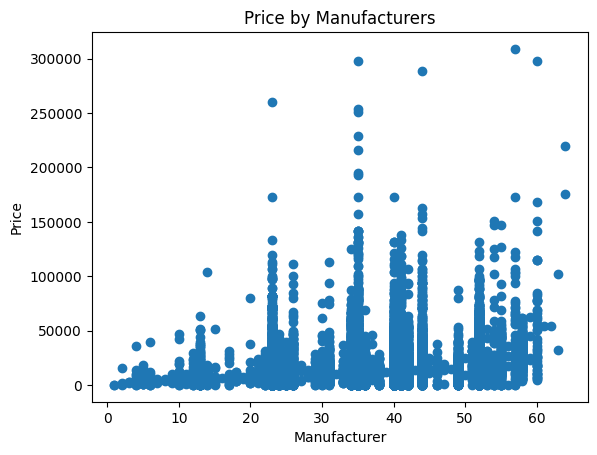

In [213]:
# Scatter plot price against manufacturer
mf_plot = df[df['price']<600000][['manufacturer', 'price']].copy()

plt.scatter(mf_plot['manufacturer'], mf_plot['price'])
plt.title('Price by Manufacturers')
plt.xlabel("Manufacturer")
plt.ylabel("Price")

plt.show()

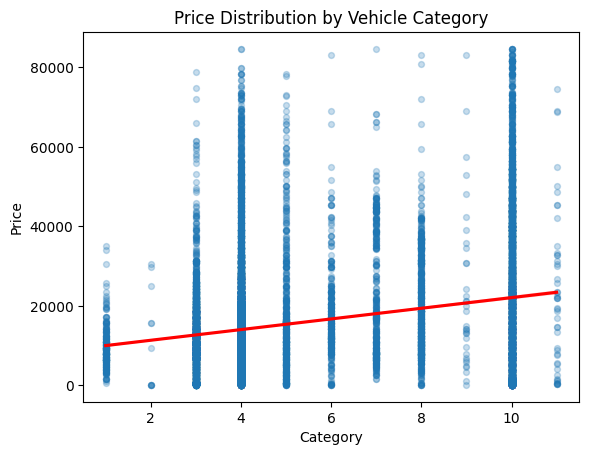

In [214]:
# Plot price with category
cat_plot = df[['category', 'price']].dropna().copy()

# Filter out extreme price values for better visualization
price_max = cat_plot['price'].quantile(0.99)
cat_plot = cat_plot[cat_plot['price'] <= price_max]

# Map category codes back to names for plotting
category_inv_map = {code: name for name, code in category_map.items()}
#cat_plot['category'] = cat_plot['category'].map(category_inv_map)


plt.scatter(cat_plot['category'], cat_plot['price'], alpha=0.25, s=18)
sns.regplot(data=cat_plot, x='category', y='price', scatter=False, color='red')
plt.title('Price Distribution by Vehicle Category')
plt.xlabel('Category')
plt.ylabel('Price')

plt.show()

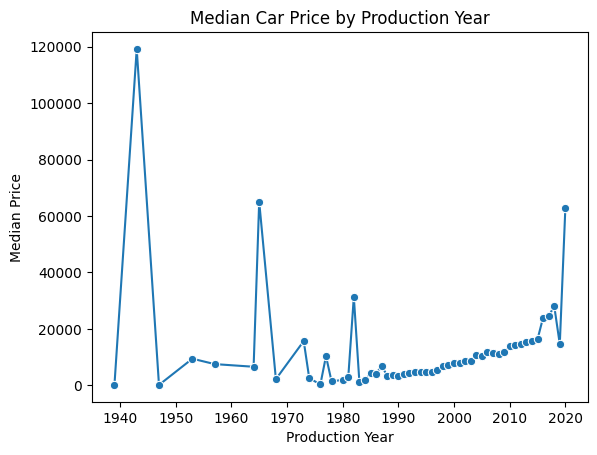

In [215]:
# Plot price with year (median trend)
year_plot = df[['year', 'price']].dropna().copy()
year_summary = (
    year_plot.groupby('year', as_index=False)['price']
    .median()
    .sort_values('year')
 )

sns.lineplot(data=year_summary, x='year', y='price', marker='o')
plt.title('Median Car Price by Production Year')
plt.xlabel('Production Year')
plt.ylabel('Median Price')

plt.show()

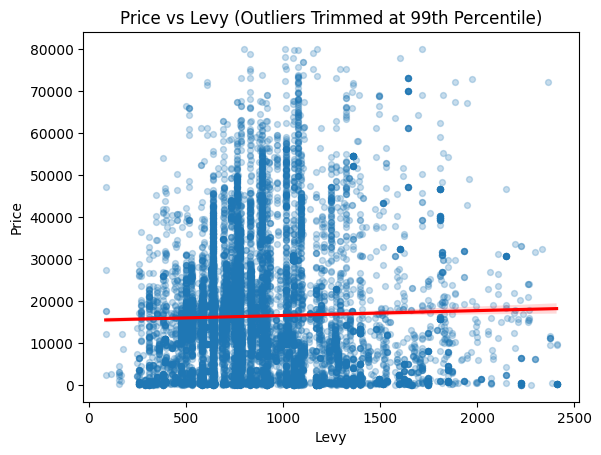

In [216]:
# Plot price with levy
levy_plot = df[['levy', 'price']].dropna().copy()
levy_plot = levy_plot[levy_plot['levy'] > 0]

# Limit extreme outliers for readability
levy_max = levy_plot['levy'].quantile(0.99)
price_max = levy_plot['price'].quantile(0.99)
levy_plot = levy_plot[(levy_plot['levy'] <= levy_max) & (levy_plot['price'] <= price_max)]

plt.scatter(levy_plot['levy'], levy_plot['price'], alpha=0.25, s=18)
sns.regplot(data=levy_plot, x='levy', y='price', scatter=False, color='red')
plt.title('Price vs Levy (Outliers Trimmed at 99th Percentile)')
plt.xlabel('Levy')
plt.ylabel('Price')

plt.show()

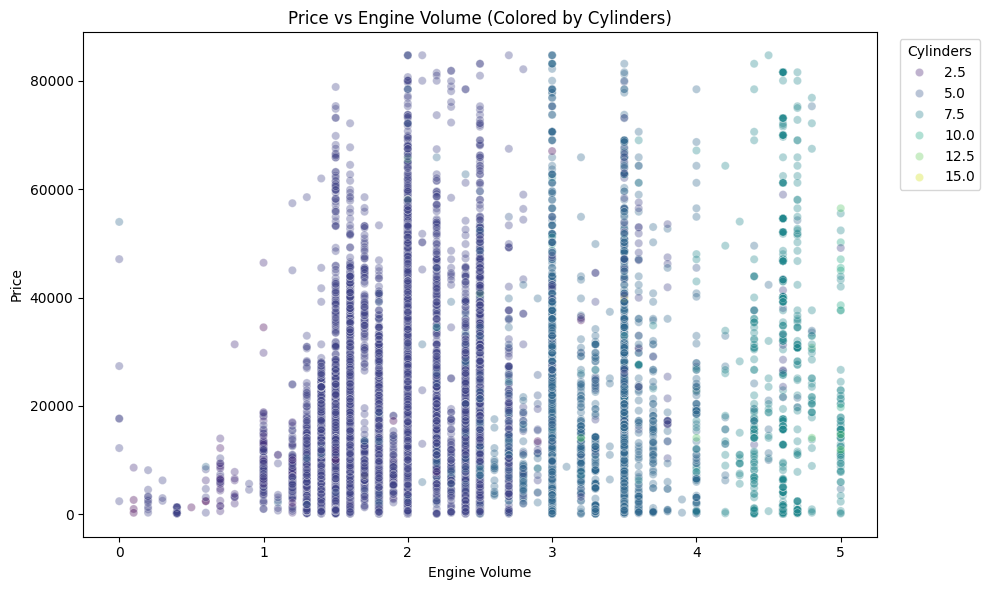

In [217]:
# Plot price with engine volume and cylinders
engine_plot = df[['engine_volume', 'cylinders', 'price']].dropna().copy()
engine_plot['engine_volume_num'] = pandas.to_numeric(
    engine_plot['engine_volume'].astype(str).str.extract(r'(\d+\.?\d*)')[0],
    errors='coerce'
 )
engine_plot = engine_plot.dropna(subset=['engine_volume_num'])

engine_max = engine_plot['engine_volume_num'].quantile(0.99)
price_max = engine_plot['price'].quantile(0.99)
engine_plot = engine_plot[(engine_plot['engine_volume_num'] <= engine_max) & (engine_plot['price'] <= price_max)]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=engine_plot,
    x='engine_volume_num',
    y='price',
    hue='cylinders',
    palette='viridis',
    alpha=0.35,
    s=35
 )
plt.title('Price vs Engine Volume (Colored by Cylinders)')
plt.xlabel('Engine Volume')
plt.ylabel('Price')
plt.legend(title='Cylinders', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Model Preparation
Select features to use in training model
Decide what kind of model to use

In [251]:
df.columns

Index(['id', 'price', 'levy', 'manufacturer', 'model', 'year', 'category',
       'leather_interior', 'fuel', 'engine_volume', 'mileage', 'cylinders',
       'gear_type', 'drive_wheels', 'doors', 'wheel', 'color', 'airbags'],
      dtype='str')

In [252]:
x = df[['year','levy','manufacturer', 'fuel','engine_volume', 'mileage', 'category']]
y = df['price']

x.info()

<class 'pandas.DataFrame'>
Index: 13339 entries, 0 to 19236
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year           13339 non-null  int64  
 1   levy           13339 non-null  int64  
 2   manufacturer   13339 non-null  int64  
 3   fuel           13339 non-null  int64  
 4   engine_volume  13339 non-null  float64
 5   mileage        13339 non-null  int64  
 6   category       13339 non-null  int64  
dtypes: float64(1), int64(6)
memory usage: 833.7 KB


In [253]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=61)

In [245]:
x_train.shape

(10671, 7)

In [254]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [223]:
model.coef_

array([ 1.95896799e+03,  5.41358002e+00,  2.86217714e+02,  2.98852094e+03,
       -9.92431018e+02,  9.53055002e-06,  1.13539839e+03])

In [255]:
y_pred = model.predict(x_test)

y_pred

array([20974.00571216, 18169.66844178, 12542.51723198, ...,
       14563.25798313, 33598.74298565, 25484.74824556], shape=(2668,))

In [225]:
y_test

12053    26343
106      12858
3347     12231
4695      6700
6503       706
         ...  
15691    16308
2690     18503
654      20005
7109       627
7315     23207
Name: price, Length: 2668, dtype: int64

## Evaluate Model Performance

In [226]:
from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error,r2_score

In [257]:
mean_absolute_error(y_test, y_pred)

10567.462436636439

In [249]:
root_mean_squared_error(y_test, y_pred)

16133.053418452575